# CCTV Anomaly Detection — v2 (Accuracy-Boosted)

### Key upgrades over v1:
| What | v1 | v2 |
|---|---|---|
| LSTM direction | Unidirectional | **Bidirectional** |
| Sequence pooling | Last hidden state only | **Multi-head self-attention** over all LSTM outputs |
| Frame features | Raw ResNet50 features | Raw + **temporal difference (motion)** features |
| Loss | CrossEntropy + class weights | CrossEntropy + class weights + **label smoothing** |
| LR schedule | ReduceLROnPlateau | **Cosine annealing with linear warmup** |
| Backbone weights | IMAGENET1K_V1 | **IMAGENET1K_V2** (higher accuracy) |
| Videos per class | 50 | **200** (more data = better generalization) |
| Inference | Single pass | **Test-time augmentation (TTA)** |


In [1]:
!pip install --upgrade -q pip
!pip install -q scipy scikit-learn matplotlib seaborn
!rm -rf /kaggle/working/keyframe_output_v2
!rm -rf TransNetV2
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/soCzech/TransNetV2.git
%cd TransNetV2
!pip install -e .

import os, cv2, json, math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ All imports successful')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.6 MB/s eta 0:00:0000:0100:01
Cloning into 'TransNetV2'...
remote: Enumerating objects: 362, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 362 (delta 71), reused 71 (delta 71), pack-reused 274 (from 1)
Receiving objects: 100% (362/362), 95.25 KiB | 2.98 MiB/s, done.
Resolving deltas: 100% (210/210), done.
/kaggle/working/TransNetV2
Obtaining file:///kaggle/working/TransNetV2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for transnetv2 (pyproject.toml) ... done
  Created wheel for transnetv2: filename=transnetv2-1.0.0-0.editable-py3-none-any.whl size=3818 sha256=50e6b938d8f1c6344e76c0c58d6975e4d198a6c59b5afce96c11855dfe6fed5b
  Stored in directory: /tmp/pip-ephem-wheel-cache-2zr2uqz9/

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR    = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data"
OUTPUT_DIR     = "/kaggle/working/keyframe_output_v2"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2"

df = pd.read_csv("/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv")
CLASSES = sorted(df.label.unique().tolist())
print(f"Classes: {CLASSES}")

# ── Hyperparameters ────────────────────────────────────────────────────
MAX_KEYFRAMES  = 350    # covers 90th+ percentile
FEATURE_DIM    = 2048   # ResNet50 output
MOTION_DIM     = 2048   # temporal diff features (same size)
INPUT_DIM      = FEATURE_DIM + MOTION_DIM  # 4096 total per frame
PROJ_DIM       = 512    # projection before LSTM
HIDDEN_SIZE    = 512    # LSTM hidden size per direction
NUM_LAYERS     = 2      # LSTM layers
NUM_HEADS      = 8      # attention heads
DROPOUT        = 0.4
BATCH_SIZE     = 16
EPOCHS         = 60
LEARNING_RATE  = 3e-4
WARMUP_EPOCHS  = 5
LABEL_SMOOTH   = 0.1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

print(f"✅ Device: {DEVICE}")
print(f"✅ Classes: {CLASS_TO_IDX}")
print(f"✅ Input dim to LSTM: {INPUT_DIM} (features + motion)")

os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Classes: ['abuse', 'arrest', 'arson', 'assault', 'burglary', 'explosion', 'fighting', 'normal', 'roadaccidents', 'robbery', 'shooting', 'shoplifting', 'stealing', 'vandalism']
✅ Device: cuda
✅ Classes: {'abuse': 0, 'arrest': 1, 'arson': 2, 'assault': 3, 'burglary': 4, 'explosion': 5, 'fighting': 6, 'normal': 7, 'roadaccidents': 8, 'robbery': 9, 'shooting': 10, 'shoplifting': 11, 'stealing': 12, 'vandalism': 13}
✅ Input dim to LSTM: 4096 (features + motion)


In [3]:
# ── Preprocessing ──────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


def load_resnet():
    """
    Load ResNet50 with IMAGENET1K_V2 weights — higher accuracy than V1.
    Fully frozen for feature extraction.
    """
    # V2 weights use better training recipe (acc: 80.9% vs 76.1% on ImageNet)
    resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
    feature_extractor = feature_extractor.to(DEVICE)
    feature_extractor.eval()
    for param in feature_extractor.parameters():
        param.requires_grad = False
    print("✅ ResNet50 (V2 weights) loaded & frozen")
    return feature_extractor


def extract_frame_features(video_path, feature_extractor, sample_rate=2):
    """
    Extract ResNet50 features for every sample_rate-th frame.
    Also computes temporal difference (motion) features as consecutive frame diffs.
    
    Returns:
        combined_features : (T, 4096) — raw features + motion features
        frame_indices     : list of frame numbers
    """
    cap = cv2.VideoCapture(str(video_path))
    raw_features  = []
    frame_indices = []
    frame_idx     = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % sample_rate == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            tensor = preprocess(frame_rgb).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                feat = feature_extractor(tensor).squeeze().cpu().numpy()  # (2048,)
            raw_features.append(feat)
            frame_indices.append(frame_idx)
        frame_idx += 1

    cap.release()

    if len(raw_features) == 0:
        return np.array([]), []

    raw_features = np.array(raw_features)  # (T, 2048)

    # ── Temporal difference (motion) features ──────────────────────
    # diff[t] = features[t] - features[t-1], capturing what changed
    motion = np.zeros_like(raw_features)   # (T, 2048), first frame = zeros
    motion[1:] = raw_features[1:] - raw_features[:-1]

    # Concatenate: raw + motion = (T, 4096)
    combined = np.concatenate([raw_features, motion], axis=1)

    return combined, frame_indices


resnet_model = load_resnet()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 


✅ ResNet50 (V2 weights) loaded & frozen


In [4]:
# ── Shot detection (unchanged from v1) ────────────────────────────────

def detect_shots_transnetv2(video_path):
    try:
        from transnetv2 import TransNetV2
        model  = TransNetV2()
        _, single_frame_predictions, _ = model.predict_video(str(video_path))
        scenes = model.predictions_to_scenes(single_frame_predictions)
        return [(int(s[0]), int(s[1])) for s in scenes]
    except ImportError:
        return detect_shots_fallback(video_path)


def detect_shots_fallback(video_path):
    cap          = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return [(0, 0)]
    boundaries = [0]
    prev_hist  = None
    THRESHOLD  = 0.5
    for frame_idx in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        hist = cv2.calcHist([frame], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
        hist = cv2.normalize(hist, hist).flatten()
        if prev_hist is not None:
            diff = cv2.compareHist(prev_hist, hist, cv2.HISTCMP_BHATTACHARYYA)
            if diff > THRESHOLD:
                boundaries.append(frame_idx)
        prev_hist = hist
    cap.release()
    boundaries.append(total_frames - 1)
    shots = [(boundaries[i], boundaries[i+1]-1) for i in range(len(boundaries)-1)]
    return shots if shots else [(0, max(0, total_frames-1))]

In [5]:
# ── Keyframe selection (unchanged from v1) ────────────────────────────

def extract_keyframes_from_shot(shot_features, shot_start_frame):
    """Percentile-based keyframe selection within a single shot."""
    num_frames = len(shot_features)
    if num_frames < 3:
        mid = num_frames // 2
        return [shot_start_frame + mid], [shot_features[mid]]

    # Use only raw features (first 2048 dims) for distance computation
    raw = shot_features[:, :FEATURE_DIM]
    mean_feat = np.mean(raw, axis=0)
    distances = np.array([np.linalg.norm(f - mean_feat) for f in raw])
    smoothed  = gaussian_filter1d(distances, sigma=1.0)

    derivative = np.zeros(len(smoothed))
    for i in range(1, len(smoothed)):
        denom = smoothed[i-1] if smoothed[i-1] != 0 else 1e-8
        derivative[i] = (smoothed[i] - smoothed[i-1]) / denom

    T1_max = np.percentile(derivative, 85)
    T2_min = np.percentile(derivative, 15)
    peaks   = np.where(derivative >= T1_max)[0]
    troughs = np.where(derivative <= T2_min)[0]
    candidates = np.union1d(peaks, troughs)
    if len(candidates) == 0:
        candidates = [int(np.argmax(distances))]

    keyframe_indices  = []
    keyframe_features = []
    WINDOW = 8

    for seg_idx in candidates:
        win_start    = max(0, seg_idx - WINDOW)
        win_end      = min(num_frames, seg_idx + WINDOW + 1)
        window_feats = raw[win_start:win_end]
        if len(window_feats) < 2:
            local_idx = 0
        else:
            motion_scores = [np.mean(np.abs(window_feats[t+1] - window_feats[t]))
                             for t in range(len(window_feats)-1)]
            local_idx = int(np.argmax(motion_scores))
        global_idx = shot_start_frame + win_start + local_idx
        keyframe_indices.append(global_idx)
        keyframe_features.append(shot_features[win_start + local_idx])  # full 4096-dim

    return keyframe_indices, keyframe_features

In [6]:
# ── Video processing pipeline ──────────────────────────────────────────

def process_video(video_path, feature_extractor):
    video_path  = Path(video_path)
    SAMPLE_RATE = 2

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    if total_frames <= 0:
        return None, None, None

    shots = detect_shots_transnetv2(video_path)

    # Returns (T, 4096) — raw + motion features
    all_features, frame_indices = extract_frame_features(
        video_path, feature_extractor, sample_rate=SAMPLE_RATE
    )

    if len(all_features) == 0:
        return None, None, None

    frame_to_feat_idx = {f: i for i, f in enumerate(frame_indices)}

    all_kf_indices  = []
    all_kf_features = []

    for (shot_start, shot_end) in shots:
        shot_start = max(0, shot_start)
        shot_end   = min(total_frames - 1, shot_end)
        if shot_start >= shot_end:
            continue
        shot_feat_indices = [
            frame_to_feat_idx[f] for f in frame_indices
            if shot_start <= f <= shot_end and f in frame_to_feat_idx
        ]
        if len(shot_feat_indices) < 2:
            continue
        shot_feats = all_features[shot_feat_indices]
        kf_idx, kf_feats = extract_keyframes_from_shot(shot_feats, shot_start)
        all_kf_indices.extend(kf_idx)
        all_kf_features.extend(kf_feats)

    seen, unique_feats = set(), []
    for idx, feat in zip(all_kf_indices, all_kf_features):
        if idx not in seen:
            seen.add(idx)
            unique_feats.append(feat)

    num_keyframes = len(unique_feats)

    if num_keyframes == 0:
        indices      = np.linspace(0, len(all_features)-1, MAX_KEYFRAMES, dtype=int)
        unique_feats = [all_features[i] for i in indices]
        num_keyframes = MAX_KEYFRAMES

    feat_dim = unique_feats[0].shape[0]  # 4096

    if num_keyframes >= MAX_KEYFRAMES:
        sample_idx     = np.linspace(0, num_keyframes-1, MAX_KEYFRAMES, dtype=int)
        final_features = np.array(unique_feats)[sample_idx]
        actual_length  = MAX_KEYFRAMES
    else:
        pad_len        = MAX_KEYFRAMES - num_keyframes
        padding        = np.zeros((pad_len, feat_dim), dtype=np.float32)
        final_features = np.vstack([np.array(unique_feats, dtype=np.float32), padding])
        actual_length  = num_keyframes

    stats = {
        "video"         : video_path.name,
        "total_frames"  : total_frames,
        "num_shots"     : len(shots),
        "num_keyframes" : num_keyframes,
        "pct_keyframes" : round(num_keyframes / total_frames * 100, 2),
        "actual_length" : actual_length,
        "fps"           : fps,
    }

    return final_features.astype(np.float32), actual_length, stats

In [7]:
# ── Dataset processing ──────────────────────────────────────────────────

def process_dataset():
    # ✅ UPGRADE: 200 videos per class (was 50) for better generalization
    MAX_VIDEOS_PER_CLASS = 200

    all_stats     = []
    feature_files = []
    labels        = []

    video_paths_all = []
    labels_all      = []

    print("📂 Scanning all class folders...\n")
    for class_name in CLASSES:
        class_dir = Path(DATASET_DIR) / class_name
        if not class_dir.exists():
            print(f"   ⚠️  Missing: {class_dir}")
            continue
        videos = (list(class_dir.glob("*.mp4")) +
                  list(class_dir.glob("*.avi")) +
                  list(class_dir.glob("*.mov")))
        if not videos:
            continue
        original_count = len(videos)
        videos = videos[:MAX_VIDEOS_PER_CLASS]
        capped = f" (capped from {original_count})" if original_count > MAX_VIDEOS_PER_CLASS else ""
        print(f"   {class_name:14s}: {len(videos):4d} videos{capped}")
        for v in videos:
            video_paths_all.append(v)
            labels_all.append(CLASS_TO_IDX[class_name])

    total = len(video_paths_all)
    print(f"\nTotal videos: {total}\n")

    for i, (video_path, label) in enumerate(zip(video_paths_all, labels_all)):
        class_name  = CLASSES[label]
        output_name = f"{class_name}_{video_path.stem}.npy"
        output_path = Path(OUTPUT_DIR) / output_name

        if output_path.exists():
            print(f"[{i+1:4d}/{total}] SKIP: {video_path.name}")
            feature_files.append(str(output_path))
            labels.append(label)
            continue

        print(f"[{i+1:4d}/{total}] {class_name:14s} | {video_path.name}", end=" ... ")
        try:
            features, actual_length, stats = process_video(video_path, resnet_model)
            if features is None:
                print("❌ empty")
                continue
            np.save(str(output_path), features)
            feature_files.append(str(output_path))
            labels.append(label)
            all_stats.append(stats)
            print(f"✅  keyframes={stats['num_keyframes']}")
        except Exception as e:
            print(f"❌ {e}")

    metadata = {
        "feature_files" : feature_files,
        "labels"        : labels,
        "class_names"   : CLASSES,
        "class_to_idx"  : CLASS_TO_IDX,
        "max_keyframes" : MAX_KEYFRAMES,
        "input_dim"     : INPUT_DIM,
    }
    metadata_path = f"{OUTPUT_DIR}/metadata.json"
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"\n✅ Metadata saved → {metadata_path}")
    return all_stats, feature_files, labels


all_stats, feature_files, labels = process_dataset()

📂 Scanning all class folders...

   abuse         :   50 videos
   arrest        :   50 videos
   arson         :   50 videos
   assault       :   50 videos
   burglary      :  100 videos
   explosion     :   50 videos
   fighting      :   50 videos
   normal        :  200 videos (capped from 950)
   roadaccidents :  150 videos
   robbery       :  150 videos
   shooting      :   50 videos
   shoplifting   :   50 videos
   stealing      :  100 videos
   vandalism     :   50 videos

Total videos: 1150

[   1/1150] abuse          | Abuse022_x264.mp4 ... ✅  keyframes=113
[   2/1150] abuse          | Abuse016_x264.mp4 ... ✅  keyframes=56
[   3/1150] abuse          | Abuse019_x264.mp4 ... ✅  keyframes=179
[   4/1150] abuse          | Abuse018_x264.mp4 ... ✅  keyframes=96
[   5/1150] abuse          | Abuse032_x264.mp4 ... ✅  keyframes=178
[   6/1150] abuse          | Abuse044_x264.mp4 ... ✅  keyframes=172
[   7/1150] abuse          | Abuse041_x264.mp4 ... ✅  keyframes=58
[   8/1150] abuse    

In [8]:
# ── Dataset & DataLoader ───────────────────────────────────────────────

class AnomalyDataset(Dataset):
    def __init__(self, feature_files, labels):
        self.feature_files = feature_files
        self.labels        = labels

    def __len__(self):
        return len(self.feature_files)

    def __getitem__(self, idx):
        features = np.load(self.feature_files[idx])  # (MAX_KEYFRAMES, 4096)
        non_zero = np.any(features != 0, axis=1)
        length   = max(1, int(np.sum(non_zero)))
        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
        )


def collate_fn(batch):
    features, labels, lengths = zip(*batch)
    return (
        torch.stack(features),
        torch.stack(labels),
        torch.stack(lengths).clamp(min=1, max=MAX_KEYFRAMES),
    )


# ── Load metadata ─────────────────────────────────────────────────────
with open(f"{OUTPUT_DIR}/metadata.json") as f:
    metadata = json.load(f)

feature_files = metadata["feature_files"]
labels        = metadata["labels"]
CLASS_NAMES   = metadata["class_names"]
num_classes   = len(CLASS_NAMES)
label_arr     = np.array(labels)

print(f"Total samples: {len(feature_files)}")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {name:14s}: {int(np.sum(label_arr == i)):4d}")

# ── Train / Val / Test split (60/20/20) ───────────────────────────────
indices = list(range(len(feature_files)))
try:
    train_val_idx, test_idx = train_test_split(
        indices, test_size=0.2, stratify=label_arr, random_state=42)
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=0.25, stratify=label_arr[train_val_idx], random_state=42)
except ValueError as e:
    print(f"⚠️  Stratified split failed: {e}. Using random split.")
    train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_idx, val_idx     = train_test_split(train_val_idx, test_size=0.25, random_state=42)


def make_loader(idx_list, shuffle):
    files = [feature_files[i] for i in idx_list]
    lbls  = [labels[i]        for i in idx_list]
    ds    = AnomalyDataset(files, lbls)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      collate_fn=collate_fn, num_workers=2, pin_memory=True)


train_loader = make_loader(train_idx, shuffle=True)
val_loader   = make_loader(val_idx,   shuffle=False)
test_loader  = make_loader(test_idx,  shuffle=False)

print(f"\nTrain: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Total samples: 1150
   abuse         :   50
   arrest        :   50
   arson         :   50
   assault       :   50
   burglary      :  100
   explosion     :   50
   fighting      :   50
   normal        :  200
   roadaccidents :  150
   robbery       :  150
   shooting      :   50
   shoplifting   :   50
   stealing      :  100
   vandalism     :   50

Train: 690 | Val: 230 | Test: 230


In [9]:
# ══════════════════════════════════════════════════════════════════════
# ✅ UPGRADE 1: Bidirectional LSTM + Multi-head Self-Attention model
# ══════════════════════════════════════════════════════════════════════

class TemporalAttentionPool(nn.Module):
    """
    Multi-head self-attention pooling over LSTM output sequence.
    
    Instead of only using the last hidden state (which loses earlier info),
    attention learns WHICH timesteps are most important for classification.
    This is especially powerful for anomaly detection — the anomalous
    moment can appear at any point in the video.
    """
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim   = hidden_size,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, x, key_padding_mask=None):
        """
        x    : (batch, seq, hidden_size) — LSTM output
        mask : (batch, seq) — True for padded positions
        """
        attn_out, attn_weights = self.attn(
            x, x, x,
            key_padding_mask=key_padding_mask,
            need_weights=True,
        )
        x = self.norm(x + attn_out)  # residual connection

        # Mean pool over non-padded positions
        if key_padding_mask is not None:
            # Invert: True means valid, False means padded
            valid_mask = (~key_padding_mask).float().unsqueeze(-1)  # (B, T, 1)
            pooled = (x * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)

        return pooled, attn_weights  # (batch, hidden_size)


class AnomalyBiLSTMAttn(nn.Module):
    """
    Architecture:
      Input (4096: raw + motion)
        → Linear Projection (512) + LayerNorm + ReLU + Dropout
        → Bidirectional 2-layer LSTM (512 per direction = 1024 total)
        → Multi-head Self-Attention pooling
        → Classifier head → num_classes
    
    Bidirectional LSTM sees both past and future context at every step,
    which is important for understanding the full context of an action.
    """

    def __init__(self, input_size, proj_dim, hidden_size, num_layers,
                 num_classes, num_heads, dropout):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_size, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.lstm = nn.LSTM(
            input_size    = proj_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = True,   # ✅ KEY UPGRADE: bidirectional
        )

        lstm_out_dim = hidden_size * 2  # 1024 (forward + backward)

        self.attn_pool = TemporalAttentionPool(
            hidden_size = lstm_out_dim,
            num_heads   = num_heads,
            dropout     = 0.1,
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, x, lengths):
        """
        x       : (batch, MAX_KEYFRAMES, 4096)
        lengths : (batch,) actual non-padded lengths
        """
        B, T, _ = x.shape

        x = self.input_proj(x)  # (B, T, 512)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.lstm(packed)  # output all hidden states
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            lstm_out, batch_first=True, total_length=T
        )  # (B, T, 1024)

        # Build padding mask for attention (True = padded position)
        pad_mask = torch.arange(T, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        pooled, _ = self.attn_pool(lstm_out, key_padding_mask=pad_mask)  # (B, 1024)

        return self.classifier(pooled)


model = AnomalyBiLSTMAttn(
    input_size  = INPUT_DIM,       # 4096
    proj_dim    = PROJ_DIM,        # 512
    hidden_size = HIDDEN_SIZE,     # 512 per direction
    num_layers  = NUM_LAYERS,      # 2
    num_classes = num_classes,
    num_heads   = NUM_HEADS,       # 8
    dropout     = DROPOUT,         # 0.4
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ AnomalyBiLSTMAttn created")
print(f"   Trainable parameters: {total_params:,}")
print(f"   LSTM output dim     : {HIDDEN_SIZE * 2} (bidirectional)")

✅ AnomalyBiLSTMAttn created
   Trainable parameters: 17,461,006
   LSTM output dim     : 1024 (bidirectional)


In [10]:
# ── Loss, Optimizer, LR Scheduler ─────────────────────────────────────

def compute_class_weights(labels, num_classes):
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    total   = len(labels)
    weights = total / (num_classes * (counts + 1e-8))
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)


train_labels  = [labels[i] for i in train_idx]
class_weights = compute_class_weights(train_labels, num_classes).to(DEVICE)

print("⚖️  Class weights:")
for name, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f"   {name:14s}: {w:.4f}")

# ✅ UPGRADE 2: Label smoothing reduces overconfidence
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-3,   # slightly higher regularization
)

# ✅ UPGRADE 3: Cosine annealing with linear warmup
# Warmup avoids large gradient updates early in training
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)
    progress = float(epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"\n✅ Criterion : CrossEntropyLoss (weighted, label_smoothing={LABEL_SMOOTH})")
print(f"✅ Optimizer : AdamW (lr={LEARNING_RATE}, weight_decay=1e-3)")
print(f"✅ Scheduler : Cosine Annealing with {WARMUP_EPOCHS}-epoch linear warmup")

⚖️  Class weights:
   abuse         : 1.2824
   arrest        : 1.2824
   arson         : 1.2824
   assault       : 1.2824
   burglary      : 0.6412
   explosion     : 1.2824
   fighting      : 1.2824
   normal        : 0.3206
   roadaccidents : 0.4275
   robbery       : 0.4275
   shooting      : 1.2824
   shoplifting   : 1.2824
   stealing      : 0.6412
   vandalism     : 1.2824

✅ Criterion : CrossEntropyLoss (weighted, label_smoothing=0.1)
✅ Optimizer : AdamW (lr=0.0003, weight_decay=1e-3)
✅ Scheduler : Cosine Annealing with 5-epoch linear warmup


In [11]:
# ── Training loop ──────────────────────────────────────────────────────

def run_epoch(model, loader, optimizer, criterion, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for features, lbls, lengths in loader:
            features = features.to(DEVICE)
            lbls     = lbls.to(DEVICE)
            lengths  = lengths.to(DEVICE)

            if training:
                optimizer.zero_grad()

            logits = model(features, lengths)
            loss   = criterion(logits, lbls)

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * features.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == lbls).sum().item()
            total      += features.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


best_val_acc   = 0.0
best_val_loss  = float("inf")
patience_count = 0
PATIENCE       = 12  # slightly more patience with cosine schedule

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

print(f"{'═'*75}")
print(f"{'Epoch':>6} │ {'LR':>8} │ {'Train Loss':>10} {'Train Acc':>10} │ {'Val Loss':>9} {'Val Acc':>9}")
print(f"{'─'*75}")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, optimizer, criterion, training=True)
    vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   optimizer, criterion, training=False)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr"].append(current_lr)

    improved = "✅" if vl_acc > best_val_acc else "  "
    print(f"{epoch:>6} │ {current_lr:>8.2e} │ {tr_loss:>10.4f} {tr_acc*100:>9.1f}% │ "
          f"{vl_loss:>9.4f} {vl_acc*100:>8.1f}% {improved}")

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save({
            "epoch"       : epoch,
            "model_state" : model.state_dict(),
            "val_loss"    : vl_loss,
            "val_acc"     : vl_acc,
            "class_names" : CLASS_NAMES,
            "num_classes" : num_classes,
            "hyperparams" : {
                "INPUT_DIM"     : INPUT_DIM,
                "PROJ_DIM"      : PROJ_DIM,
                "HIDDEN_SIZE"   : HIDDEN_SIZE,
                "NUM_LAYERS"    : NUM_LAYERS,
                "NUM_HEADS"     : NUM_HEADS,
                "DROPOUT"       : DROPOUT,
                "MAX_KEYFRAMES" : MAX_KEYFRAMES,
            }
        }, f"{CHECKPOINT_DIR}/best_model_v2.pth")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n⏹️  Early stopping at epoch {epoch}")
            break

print(f"{'═'*75}")
print(f"✅ Best val accuracy: {best_val_acc*100:.2f}%")

═══════════════════════════════════════════════════════════════════════════
 Epoch │       LR │ Train Loss  Train Acc │  Val Loss   Val Acc
───────────────────────────────────────────────────────────────────────────
     1 │ 1.20e-04 │     2.7141      11.7% │    2.6414     23.5% ✅
     2 │ 1.80e-04 │     2.5348      24.9% │    2.4619     37.0% ✅
     3 │ 2.40e-04 │     2.2938      33.5% │    2.4290     27.0%   
     4 │ 3.00e-04 │     2.0364      44.5% │    2.6610     33.9%   
     5 │ 3.00e-04 │     1.9178      47.5% │    2.5606     30.4%   
     6 │ 3.00e-04 │     1.6026      61.2% │    2.8502     28.3%   
     7 │ 2.99e-04 │     1.3341      70.6% │    2.7463     37.4% ✅
     8 │ 2.98e-04 │     1.1870      79.3% │    2.7954     33.9%   
     9 │ 2.96e-04 │     1.1391      81.2% │    2.9525     29.6%   
    10 │ 2.94e-04 │     1.0058      88.0% │    3.1590     35.2%   
    11 │ 2.91e-04 │     0.9616      89.3% │    2.9627     35.7%   
    12 │ 2.88e-04 │     0.9549      90.0% │    2.9

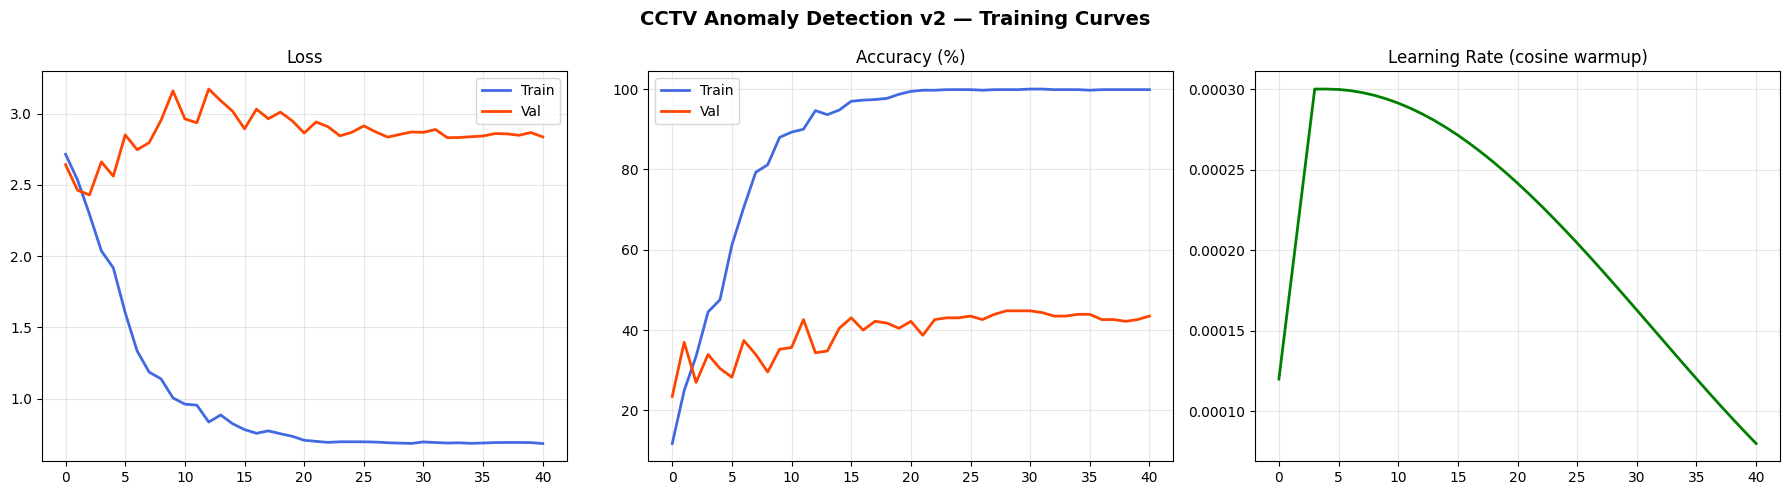

In [12]:
# ── Training curves ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train", color="royalblue", lw=2)
axes[0].plot(history["val_loss"],   label="Val",   color="orangered", lw=2)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in history["train_acc"]], label="Train", color="royalblue", lw=2)
axes[1].plot([a*100 for a in history["val_acc"]],   label="Val",   color="orangered", lw=2)
axes[1].set_title("Accuracy (%)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history["lr"], color="green", lw=2)
axes[2].set_title("Learning Rate (cosine warmup)"); axes[2].grid(True, alpha=0.3)

plt.suptitle("CCTV Anomaly Detection v2 — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v2.png", dpi=150)
plt.show()

✅ Loaded best model (epoch 29, val_acc=44.78%)

🎯 Test Accuracy: 36.52%

📊 Classification Report:
               precision    recall  f1-score   support

        abuse       0.44      0.40      0.42        10
       arrest       0.20      0.10      0.13        10
        arson       0.29      0.40      0.33        10
      assault       0.00      0.00      0.00        10
     burglary       0.26      0.40      0.31        20
    explosion       0.50      0.30      0.38        10
     fighting       0.00      0.00      0.00        10
       normal       0.62      0.62      0.62        40
roadaccidents       0.40      0.33      0.36        30
      robbery       0.41      0.53      0.46        30
     shooting       0.00      0.00      0.00        10
  shoplifting       0.40      0.40      0.40        10
     stealing       0.50      0.45      0.47        20
    vandalism       0.00      0.00      0.00        10

     accuracy                           0.37       230
    macro avg       

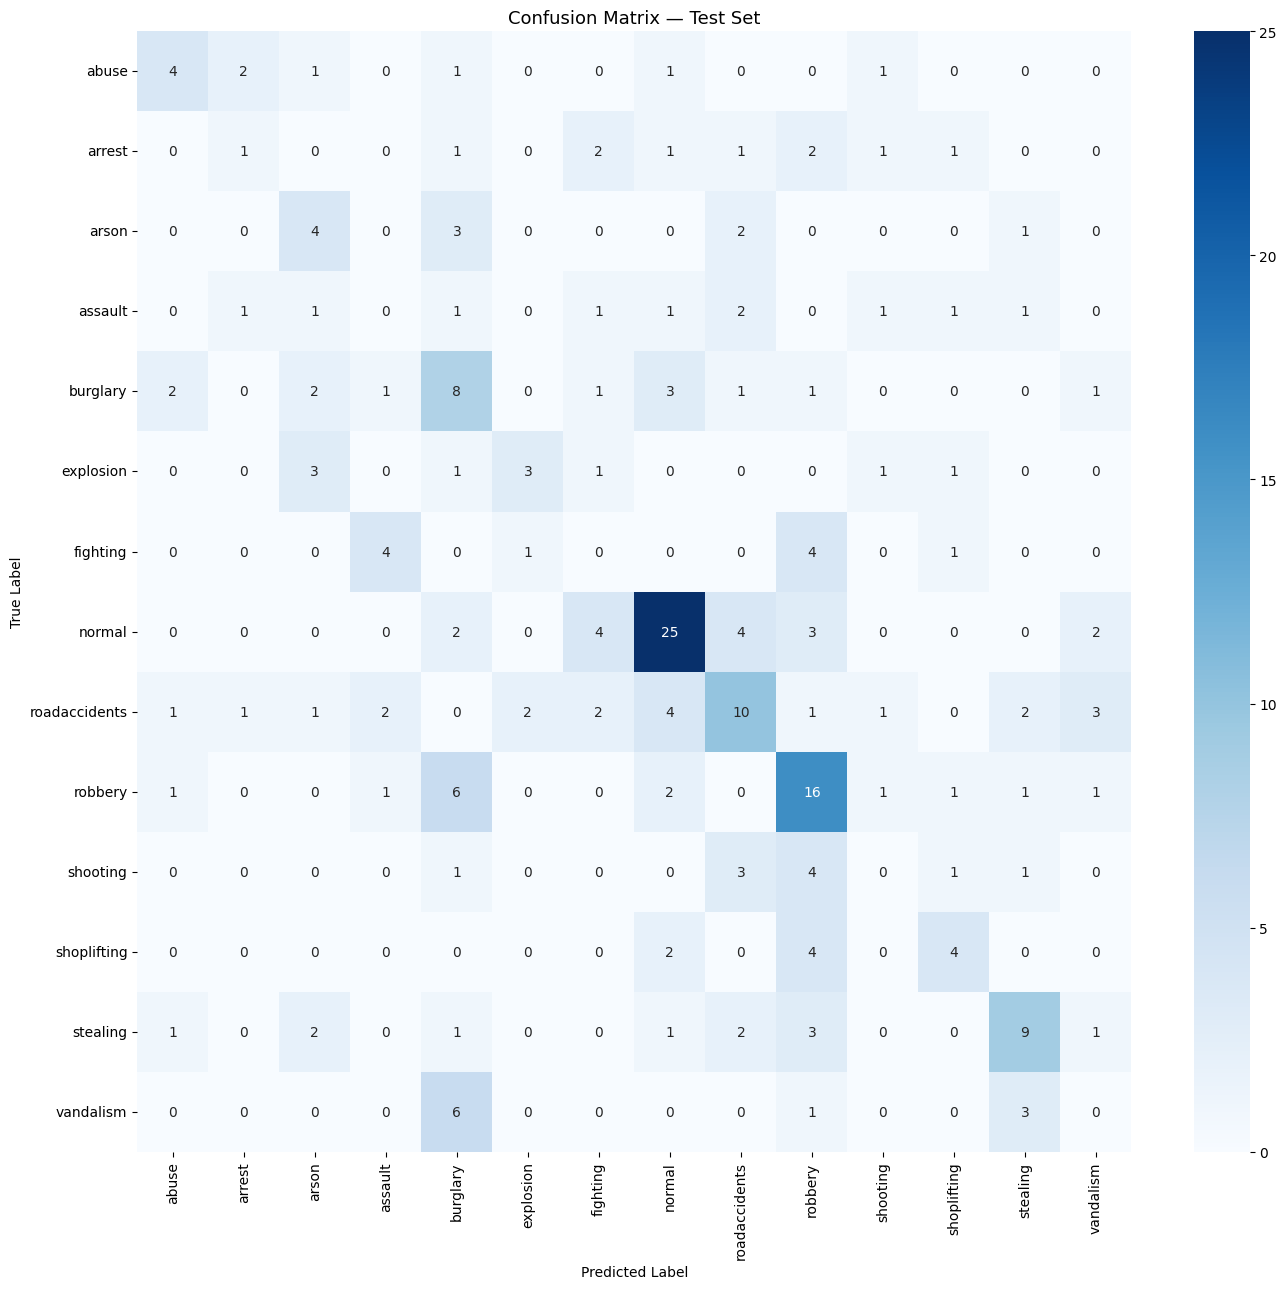

In [13]:
# ── Test set evaluation with classification report ─────────────────────

# Load best checkpoint
checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model_v2.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"✅ Loaded best model (epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']*100:.2f}%)")

_, test_acc, test_preds, test_labels_list = run_epoch(
    model, test_loader, optimizer, criterion, training=False
)

print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(test_labels_list, test_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels_list, test_preds)
plt.figure(figsize=(max(8, num_classes), max(6, num_classes-1)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Test Set", fontsize=13)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_v2.png", dpi=150)
plt.show()

In [14]:
# ── Inference with TTA (Test-Time Augmentation) ────────────────────────
#
# TTA: run inference multiple times with slightly different frame sampling,
# then average the probability predictions. Reduces variance.

def predict_single_video_tta(video_path, feature_extractor=None, clf_model=None, n_tta=3):
    """
    Predict video class with Test-Time Augmentation.
    
    n_tta: number of TTA passes (each uses a slightly different frame offset)
    Averaging predictions across passes reduces prediction variance.
    """
    if feature_extractor is None:
        feature_extractor = resnet_model
    if clf_model is None:
        clf_model = model

    video_path = Path(video_path)
    print(f"\n🎥 Predicting (TTA x{n_tta}): {video_path.name}")

    all_probs = []

    for tta_idx in range(n_tta):
        # Each TTA pass uses a slightly different sample rate offset
        # to see different frames of the video
        sample_rate = 2
        frame_offset = tta_idx  # 0, 1, 2 → samples from different starting points

        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        features_list = []
        frame_indices = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if (frame_idx + frame_offset) % sample_rate == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                tensor = preprocess(frame_rgb).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    feat = feature_extractor(tensor).squeeze().cpu().numpy()
                features_list.append(feat)
                frame_indices.append(frame_idx)
            frame_idx += 1
        cap.release()

        if len(features_list) == 0:
            continue

        raw = np.array(features_list)  # (T, 2048)
        motion = np.zeros_like(raw)
        motion[1:] = raw[1:] - raw[:-1]
        all_feats = np.concatenate([raw, motion], axis=1)  # (T, 4096)

        T = len(all_feats)
        if T >= MAX_KEYFRAMES:
            idx    = np.linspace(0, T-1, MAX_KEYFRAMES, dtype=int)
            feats  = all_feats[idx]
            length = MAX_KEYFRAMES
        else:
            pad   = np.zeros((MAX_KEYFRAMES - T, INPUT_DIM), dtype=np.float32)
            feats = np.vstack([all_feats, pad])
            length = T

        feat_t   = torch.tensor(feats, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        length_t = torch.tensor([length], dtype=torch.long).to(DEVICE)

        clf_model.eval()
        with torch.no_grad():
            logits = clf_model(feat_t, length_t)
            probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        all_probs.append(probs)

    if not all_probs:
        print("❌ Could not process video.")
        return None, None

    # Average TTA predictions
    avg_probs = np.mean(all_probs, axis=0)
    pred = int(np.argmax(avg_probs))

    print(f"\n{'═'*50}")
    print(f"  PREDICTION → {CLASS_NAMES[pred].upper()}")
    print(f"{'═'*50}")
    for i, (name, prob) in enumerate(zip(CLASS_NAMES, avg_probs)):
        bar    = "█" * int(prob * 30)
        marker = " ← predicted" if i == pred else ""
        print(f"  {name:14s}: {prob*100:5.1f}%  {bar}{marker}")

    return CLASS_NAMES[pred], avg_probs


print("✅ predict_single_video_tta() ready")
print("   Usage: predict_single_video_tta('/path/to/video.mp4', n_tta=3)")

✅ predict_single_video_tta() ready
   Usage: predict_single_video_tta('/path/to/video.mp4', n_tta=3)


In [15]:
# ── Quick sanity check on example videos ──────────────────────────────

predict_single_video_tta(
    "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/arrest/Arrest001_x264.mp4",
    n_tta=3
)

predict_single_video_tta(
    "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/normal/Normal_Videos004_x264.mp4",
    n_tta=3
)


🎥 Predicting (TTA x3): Arrest001_x264.mp4

══════════════════════════════════════════════════
  PREDICTION → ROBBERY
══════════════════════════════════════════════════
  abuse         :   1.9%  
  arrest        :   2.1%  
  arson         :   1.8%  
  assault       :   1.7%  
  burglary      :   0.9%  
  explosion     :   1.7%  
  fighting      :   1.8%  
  normal        :   0.4%  
  roadaccidents :   0.6%  
  robbery       :  80.9%  ████████████████████████ ← predicted
  shooting      :   1.7%  
  shoplifting   :   1.8%  
  stealing      :   0.9%  
  vandalism     :   1.7%  

🎥 Predicting (TTA x3): Normal_Videos004_x264.mp4

══════════════════════════════════════════════════
  PREDICTION → NORMAL
══════════════════════════════════════════════════
  abuse         :   3.2%  
  arrest        :   3.0%  
  arson         :   3.0%  
  assault       :   3.2%  
  burglary      :   1.7%  
  explosion     :   2.8%  
  fighting      :   2.6%  
  normal        :  68.6%  ████████████████████ ← pred

('normal',
 array([0.03159202, 0.03025781, 0.02971375, 0.03160326, 0.01652133,
        0.02820661, 0.0261752 , 0.686112  , 0.01030416, 0.01009837,
        0.02812736, 0.02854851, 0.01552748, 0.02721208], dtype=float32))

In [16]:
# ── Save full model package ────────────────────────────────────────────

import shutil

SAVE_DIR = "/kaggle/working/anomaly_model_v2_package"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "model_state"  : model.state_dict(),
    "num_classes"  : num_classes,
    "class_names"  : CLASS_NAMES,
    "class_to_idx" : CLASS_TO_IDX,
    "hyperparams"  : {
        "INPUT_DIM"     : INPUT_DIM,
        "PROJ_DIM"      : PROJ_DIM,
        "HIDDEN_SIZE"   : HIDDEN_SIZE,
        "NUM_LAYERS"    : NUM_LAYERS,
        "NUM_HEADS"     : NUM_HEADS,
        "DROPOUT"       : DROPOUT,
        "MAX_KEYFRAMES" : MAX_KEYFRAMES,
    }
}, f"{SAVE_DIR}/anomaly_bilstm_attn.pth")

config = {
    "CLASS_NAMES"   : CLASS_NAMES,
    "CLASS_TO_IDX"  : CLASS_TO_IDX,
    "INPUT_DIM"     : INPUT_DIM,
    "FEATURE_DIM"   : FEATURE_DIM,
    "PROJ_DIM"      : PROJ_DIM,
    "HIDDEN_SIZE"   : HIDDEN_SIZE,
    "NUM_LAYERS"    : NUM_LAYERS,
    "NUM_HEADS"     : NUM_HEADS,
    "DROPOUT"       : DROPOUT,
    "MAX_KEYFRAMES" : MAX_KEYFRAMES,
    "SAMPLE_RATE"   : 2,
    "MODEL_VERSION" : "v2_bilstm_attention",
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

shutil.make_archive("/kaggle/working/anomaly_model_v2_package", "zip", SAVE_DIR)

print("✅ Saved: anomaly_bilstm_attn.pth")
print("✅ Saved: config.json")
print("✅ Zipped: anomaly_model_v2_package.zip")

print(f"\n📦 Package contents:")
for f in sorted(Path(SAVE_DIR).iterdir()):
    print(f"   {f.name:35s} {f.stat().st_size/1024/1024:.2f} MB")

✅ Saved: anomaly_bilstm_attn.pth
✅ Saved: config.json
✅ Zipped: anomaly_model_v2_package.zip

📦 Package contents:
   anomaly_bilstm_attn.pth             66.62 MB
   config.json                         0.00 MB
